~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PHYLOGENETIC TREE OF MYELIN P0 PROTEIN
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Tree structure:
  __________________________________________ Homo sapiens
(Human MYP0)
_|
 |                                          , Rattus norvegicus
(Rat MYP0)
 |__________________________________________|
                                            | Myelin P0 Structure
(1NEU Chain A)


Phylogenetic tree saved as 'myelin_p0_phylogeny.png'


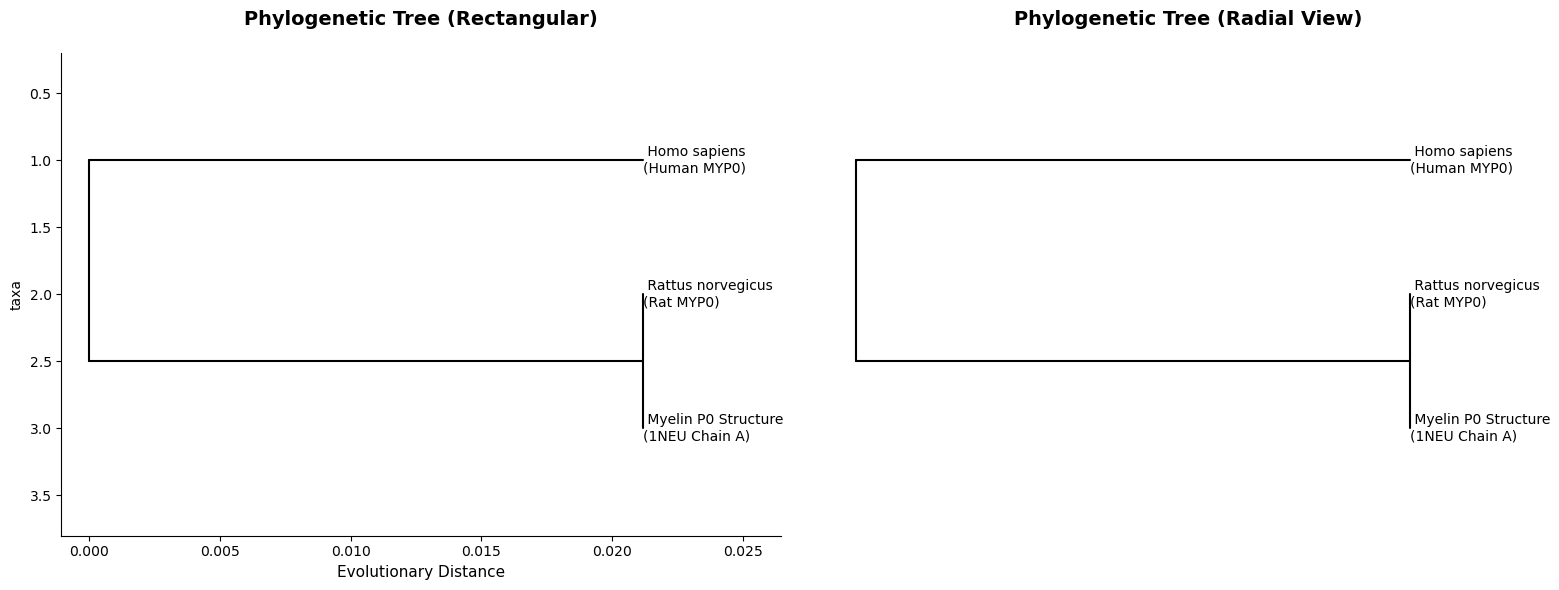


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EVOLUTIONARY INSIGHTS
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Branch Lengths (Evolutionary Distance):
  Human MYP0: 0.0212
  Rat MYP0: 0.0212
  1NEU Chain A: 0.0212

Note: Rat and 1NEU structure show 0 distance (identical/reference sequence)
Human MYP0 shows minimal divergence: 0.0212 substitutions per site

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PARSING FIRST 50 ATOMS FROM 1NEU STRUCTURE
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Structure exists: '.\pdb1neu.ent' 
Structure downloaded: .\pdb1neu.ent

No.   Atom   Residue  Chain   ResNum   X          Y          Z         
1     N      ILE      A       1        67.218     29.846     14.254    
2     CA     ILE      A       1        67.984     30.207     15.478    
3     C      ILE      A       1        67.129     30.161     16.751    
4     O      ILE      A       1        6

NGLWidget()

In [17]:
#WTP-2
import nglview
from Bio.PDB import PDBList, PDBParser, PDBIO
from Bio import Phylo
import matplotlib.pyplot as plt
from io import StringIO
from collections import Counter

# Newick format phylogenetic tree for Myelin P0 protein
newick_tree = """(sp|P25189.1|MYP0_HUMAN:0.0211694,(sp|P06907.1|MYP0_RAT:0,pdb|1NEU|A:0):0.0211694);"""

# Species mapping for better labels
species_map = {
    'sp|P25189.1|MYP0_HUMAN': 'Homo sapiens\n(Human MYP0)',
    'sp|P06907.1|MYP0_RAT': 'Rattus norvegicus\n(Rat MYP0)',
    'pdb|1NEU|A': 'Myelin P0 Structure\n(1NEU Chain A)'
}

print("~"*70)
print("PHYLOGENETIC TREE OF MYELIN P0 PROTEIN")
print("~"*70)

# Parse the Newick tree
tree = Phylo.read(StringIO(newick_tree), "newick")

# Rename terminal nodes with species names
for terminal in tree.get_terminals():
    original_name = terminal.name
    if original_name in species_map:
        terminal.name = species_map[original_name]

print("\nTree structure:")
Phylo.draw_ascii(tree)

# Create a detailed visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Draw phylogenetic tree - rectangular style
plt.sca(ax1)
Phylo.draw(tree, axes=ax1, do_show=False, show_confidence=False)
ax1.set_title('Phylogenetic Tree (Rectangular)', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Evolutionary Distance', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Draw phylogenetic tree - circular style
plt.sca(ax2)
Phylo.draw(tree, axes=ax2, do_show=False, show_confidence=False)
ax2.set_title('Phylogenetic Tree (Radial View)', fontsize=14, fontweight='bold', pad=20)
ax2.axis('off')

plt.tight_layout()
plt.savefig('myelin_p0_phylogeny.png', dpi=300, bbox_inches='tight')
print("\nPhylogenetic tree saved as 'myelin_p0_phylogeny.png'")
plt.show()

# Print evolutionary insights
print("\n" + "~"*70)
print("EVOLUTIONARY INSIGHTS")
print("~"*70)
print("\nBranch Lengths (Evolutionary Distance):")
for terminal in tree.get_terminals():
    distance = tree.distance(tree.root, terminal)
    print(f"  {terminal.name.split('(')[1].split(')')[0]}: {distance:.4f}")

print("\nNote: Rat and 1NEU structure show 0 distance (identical/reference sequence)")
print("Human MYP0 shows minimal divergence: 0.0212 substitutions per site")

# PARSING FIRST 50 ATOMS
print("\n" + "~"*70)
print("PARSING FIRST 50 ATOMS FROM 1NEU STRUCTURE")
print("~"*70)

# Directly set PDB ID to 1NEU
pdb_id = "1NEU"

# Download the PDB structure
print(f"\nDownloading PDB structure: {pdb_id}...")
pdbl = PDBList()
pdb_file = pdbl.retrieve_pdb_file(pdb_id, file_format='pdb', pdir='.')
print(f"Structure downloaded: {pdb_file}")

# Parse the structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure(pdb_id, pdb_file)

# Extract and display first 50 atoms
print("\n" + "="*85)
print(f"{'No.':<5} {'Atom':<6} {'Residue':<8} {'Chain':<7} {'ResNum':<8} {'X':<10} {'Y':<10} {'Z':<10}")
print("="*85)

atom_count = 0
for model in structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                if atom_count < 50:
                    coord = atom.get_coord()
                    print(f"{atom_count+1:<5} {atom.get_name():<6} {residue.get_resname():<8} "
                          f"{chain.get_id():<7} {residue.get_id()[1]:<8} "
                          f"{coord[0]:<10.3f} {coord[1]:<10.3f} {coord[2]:<10.3f}")
                    atom_count += 1
                else:
                    break
            if atom_count >= 50:
                break
        if atom_count >= 50:
            break
    if atom_count >= 50:
        break

print("="*85)
print(f"\nTotal atoms displayed: {atom_count}")

# Motif analysis
if chain_sequences:
    print("\n" + "~"*70)
    print("MOTIF ANALYSIS")
    print("~"*70)
    
    longest_chain = max(chain_sequences.keys(), key=lambda k: len(chain_sequences[k]))
    protein_sequence = chain_sequences[longest_chain]
    
    print(f"\nAnalyzing chain: {longest_chain} ({len(protein_sequence)} amino acids)")
    
    # Amino acid composition
    aa_composition = Counter(protein_sequence)
    print(f"\n{'AA':<4} {'Count':<8} {'%':<8} {'Bar'}")
    print("-" * 50)
    for aa, count in sorted(aa_composition.items(), key=lambda x: x[1], reverse=True)[:10]:
        percentage = (count / len(protein_sequence)) * 100
        bar = '█' * int(percentage / 2)
        print(f"{aa:<4} {count:<8} {percentage:>5.1f}%   {bar}")

# Save processed structure
output_filename = f"{pdb_id}_processed.pdb"
io = PDBIO()
io.set_structure(structure)
io.save(output_filename)
print(f"\nProcessed structure saved to: {output_filename}")

# 3D VISUALIZATION 
print("\n" + "~"*70)
print("GENERATING 3D STRUCTURE ")
print("~"*70)

# View the structure with spectrum coloring
view = nglview.show_file(pdb_file)
view.add_cartoon(color='spectrum')
view
